# LT-CCD Cluster Visual Verification with Sentinel-2

This notebook supports manual visual verification of LT-CCD damage clusters using Sentinel-2 imagery.

## Goal
The notebook:
- loads LT-CCD damage clusters or polygons
- assigns sequential cluster IDs for convenient review
- loads Sentinel-2 pre-event and post-event imagery
- selects either a random cluster or a user-defined cluster ID
- extracts a rectangular image chip around the selected cluster with a configurable buffer
- displays pre-event and post-event views side by side
- overlays the target cluster boundary in red

## Input
- LT-CCD cluster polygons
- Sentinel-2 pre-event image
- Sentinel-2 post-event image

## Output
- Side-by-side visual verification panels
- Optional CSV / GeoJSON with sequential IDs

In [2521]:
import os
import random
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.windows import from_bounds
from rasterio.plot import reshape_as_image
from rasterio.enums import Resampling
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from typing import Optional
from shapely.geometry import box

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


In [2522]:
# =========================
# INPUT PATHS
# =========================

# Preferred input: dissolved clusters from Notebook 3
clusters_path = Path("/Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/cluster_filtering/ltccd_damage_polygons_with_cluster_id.geojson")

# AOI is optional for context
aoi_path = Path("/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/Teheran_AOI/Teheran_AOI.geojson")

# Sentinel-2 pre-event and post-event images
s2_pre_path = Path("/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/Teheran_S2/20260220_Teheran_projeziert.tif")
s2_post_path = Path("/Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/Teheran_S2/20260327_Teheran_projeziert.tif")

# =========================
# OUTPUTS
# =========================
output_dir = Path("/Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/visual_verification")
output_dir.mkdir(parents=True, exist_ok=True)

clusters_with_seq_path = output_dir / "ltccd_clusters_with_seq_id.geojson"
clusters_with_seq_csv = output_dir / "ltccd_clusters_with_seq_id.csv"

review_geojson_path = output_dir / "ltccd_clusters_review.geojson"
review_csv_path = output_dir / "ltccd_clusters_review.csv"

# =========================
# USER CONTROLS
# =========================

# If None -> random cluster will be chosen
selected_cluster_id_seq = None

# Rectangular buffer around target polygon in meters
buffer_m = 200.0   # try 50, 80, 100

# Sentinel-2 display settings
# Adjust if your S2 file has different band order
rgb_band_indices = (1, 2, 3)  # 1-based indexing for rasterio.read(); update if needed

# Contrast stretch percentiles
stretch_p_low = 2
stretch_p_high = 98

print("📋 Configuration loaded:")
print(f"   Clusters path: {clusters_path}")
print(f"   Sentinel-2 PRE path: {s2_pre_path}")
print(f"   Sentinel-2 POST path: {s2_post_path}")
print(f"   Output directory: {output_dir}")
print(f"   Selected cluster_id_seq: {selected_cluster_id_seq}")
print(f"   Buffer: {buffer_m} m")
print(f"   RGB band indices: {rgb_band_indices}")
print(f"   Stretch percentiles: {stretch_p_low}-{stretch_p_high}")

📋 Configuration loaded:
   Clusters path: /Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/cluster_filtering/ltccd_damage_polygons_with_cluster_id.geojson
   Sentinel-2 PRE path: /Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/Teheran_S2/20260220_Teheran_projeziert.tif
   Sentinel-2 POST path: /Volumes/ChaikaT7/LT_CCD_damage/Data/Row_Data/Teheran_S2/20260327_Teheran_projeziert.tif
   Output directory: /Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/visual_verification
   Selected cluster_id_seq: None
   Buffer: 200.0 m
   RGB band indices: (1, 2, 3)
   Stretch percentiles: 2-98


In [2523]:
def load_single_feature_layer(path: Path) -> gpd.GeoDataFrame:
    """Load vector layer and dissolve if needed only when explicitly requested elsewhere."""
    gdf = gpd.read_file(path)
    if gdf.empty:
        raise ValueError(f"Layer is empty: {path}")
    return gdf


def ensure_metric_crs(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Reproject to a metric CRS if current CRS is geographic."""
    if gdf.crs is None:
        raise ValueError("GeoDataFrame has no CRS.")
    if gdf.crs.is_geographic:
        return gdf.to_crs(gdf.estimate_utm_crs())
    return gdf


def assign_sequential_cluster_ids(gdf: gpd.GeoDataFrame, source_cluster_col: str = "cluster_id") -> gpd.GeoDataFrame:
    """
    Ensure there is a clean sequential cluster ID column from 1..N.
    If source_cluster_col exists, preserve it and sort by it.
    """
    gdf = gdf.copy()

    if source_cluster_col in gdf.columns:
        gdf = gdf.sort_values(by=source_cluster_col).reset_index(drop=True)
    else:
        gdf = gdf.reset_index(drop=True)

    gdf["cluster_id_seq"] = np.arange(1, len(gdf) + 1)
    return gdf


def choose_cluster(gdf: gpd.GeoDataFrame, cluster_id_seq: Optional[int] = None) -> gpd.GeoDataFrame:
    """Return a single-row GeoDataFrame for the selected cluster."""
    if cluster_id_seq is None:
        row = gdf.sample(1, random_state=None)
    else:
        row = gdf[gdf["cluster_id_seq"] == cluster_id_seq].copy()
        if len(row) == 0:
            raise ValueError(f"cluster_id_seq={cluster_id_seq} not found.")
    return row


def get_buffered_bounds(geom, buffer_m: float):
    """Return rectangular buffered bounds."""
    minx, miny, maxx, maxy = geom.bounds
    return (minx - buffer_m, miny - buffer_m, maxx + buffer_m, maxy + buffer_m)


def read_rgb_chip(raster_path: Path, bounds, target_crs, rgb_band_indices=(1, 2, 3)):
    """
    Read a rectangular RGB chip from a multiband raster.
    Reprojects bounds only if raster CRS differs from target CRS.
    """
    with rasterio.open(raster_path) as src:
        # Transform bounds if needed
        if src.crs != target_crs:
            bbox_geom = box(*bounds)
            temp_gdf = gpd.GeoDataFrame(geometry=[bbox_geom], crs=target_crs).to_crs(src.crs)
            bounds_src = temp_gdf.total_bounds
        else:
            bounds_src = bounds

        window = from_bounds(*bounds_src, transform=src.transform)
        window = window.round_offsets().round_lengths()

        data = src.read(list(rgb_band_indices), window=window, boundless=True, fill_value=0)
        transform = src.window_transform(window)
        chip_bounds = rasterio.windows.bounds(window, src.transform)
        raster_crs = src.crs

    img = np.transpose(data, (1, 2, 0)).astype("float32")
    return img, transform, chip_bounds, raster_crs


def stretch_rgb(img, p_low=2, p_high=98):
    """Apply percentile stretch per channel."""
    img_out = np.zeros_like(img, dtype="float32")

    for i in range(img.shape[2]):
        band = img[:, :, i]
        valid = band[np.isfinite(band)]

        if valid.size == 0:
            continue

        lo = np.percentile(valid, p_low)
        hi = np.percentile(valid, p_high)

        if hi <= lo:
            img_out[:, :, i] = 0
        else:
            img_out[:, :, i] = np.clip((band - lo) / (hi - lo), 0, 1)

    return img_out


def plot_cluster_boundary(ax, cluster_gdf, target_crs, color="red", linewidth=2):
    """Plot cluster boundary in the CRS of the image chip."""
    cluster_plot = cluster_gdf.to_crs(target_crs)
    cluster_plot.boundary.plot(ax=ax, color=color, linewidth=linewidth)


def print_cluster_info(cluster_row):
    """Print basic cluster information."""
    row = cluster_row.iloc[0]
    print("📌 Selected cluster:")
    for col in cluster_row.columns:
        if col == "geometry":
            continue
        print(f"   {col}: {row[col]}")

def bounds_to_extent(bounds):
    """
    Convert raster bounds tuple to matplotlib extent.
    Bounds format: (left, bottom, right, top)
    """
    return [bounds[0], bounds[2], bounds[1], bounds[3]]

def initialize_review_table(clusters_gdf: gpd.GeoDataFrame, review_geojson_path: Path) -> gpd.GeoDataFrame:
    """
    Load existing review table if it exists, otherwise create a new one.
    Existing manual labels are preserved.
    """
    base = clusters_gdf.copy()

    review_cols = ["review_status", "review_type", "review_comment", "review_date"]

    if review_geojson_path.exists():
        existing = gpd.read_file(review_geojson_path)

        # Keep only needed columns from existing review file
        keep_cols = ["cluster_id_seq"] + [c for c in review_cols if c in existing.columns]
        existing = existing[keep_cols].copy()

        # Merge existing review info into current clusters
        base = base.merge(existing, on="cluster_id_seq", how="left")
    else:
        for col in review_cols:
            base[col] = None

    # Ensure columns exist
    for col in review_cols:
        if col not in base.columns:
            base[col] = None

    return base

def save_review_table(review_gdf: gpd.GeoDataFrame, review_geojson_path: Path, review_csv_path: Path):
    """Save review table to GeoJSON and CSV."""
    review_gdf.to_file(review_geojson_path, driver="GeoJSON")
    pd.DataFrame(review_gdf.drop(columns="geometry")).to_csv(review_csv_path, index=False)

def print_existing_review(cluster_row: gpd.GeoDataFrame):
    row = cluster_row.iloc[0]

    print("\n📝 Existing review status:")
    print(f"   review_status: {row.get('review_status', None)}")
    print(f"   review_type: {row.get('review_type', None)}")
    print(f"   review_comment: {row.get('review_comment', None)}")
    print(f"   review_date: {row.get('review_date', None)}")

def choose_next_unreviewed(gdf: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """Return the first cluster without review_status."""
    unreviewed = gdf[gdf["review_status"].isna() | (gdf["review_status"] == "")]
    if len(unreviewed) == 0:
        raise ValueError("All clusters already have a review_status.")
    return unreviewed.sort_values("cluster_id_seq").iloc[[0]].copy()

In [2524]:
print("📂 Loading LT-CCD clusters...")

clusters_gdf = load_single_feature_layer(clusters_path)
clusters_gdf = ensure_metric_crs(clusters_gdf)

print(f"   ✅ Loaded {len(clusters_gdf):,} cluster features")
print(f"   CRS: {clusters_gdf.crs}")
print(f"   Columns: {list(clusters_gdf.columns)}")

clusters_gdf = assign_sequential_cluster_ids(clusters_gdf, source_cluster_col="cluster_id" if "cluster_id" in clusters_gdf.columns else None)

print("\n✅ Sequential IDs assigned")
display(clusters_gdf.head())

print("🗺️ Loading AOI...")
aoi_gdf = load_single_feature_layer(aoi_path)
aoi_gdf = aoi_gdf.to_crs(clusters_gdf.crs)

print(f"   ✅ AOI loaded")
print(f"   CRS: {aoi_gdf.crs}")

📂 Loading LT-CCD clusters...
   ✅ Loaded 180 cluster features
   CRS: EPSG:32639
   Columns: ['area_m2', 'processing_date', 'z_threshold', 'delta_threshold', 'delta_gamma_mean', 'z_score_mean', 'damage_class', 'centroid_x', 'centroid_y', 'cluster_id', 'geometry']

✅ Sequential IDs assigned


,area_m2,processing_date,z_threshold,delta_threshold,delta_gamma_mean,z_score_mean,damage_class,centroid_x,centroid_y,cluster_id,geometry,cluster_id_seq
0,9600.0,2026-04-08,-2,-0.2,-0.284118,-4.183229,High,544026.666667,3.961993e+06,-1,"POLYGON ((543980 3962060, 544020 3962060, 5440...",1
1,25600.0,2026-04-08,-2,-0.2,-0.361571,-6.535539,Severe,534910.000000,3.949080e+06,-1,"POLYGON ((534820 3949140, 534980 3949140, 5349...",2
2,3200.0,2026-04-08,-2,-0.2,-0.261245,-3.112244,High,547540.000000,3.948760e+06,-1,"POLYGON ((547500 3948780, 547580 3948780, 5475...",3
3,41600.0,2026-04-08,-2,-0.2,-0.506760,-7.876698,Severe,546630.769231,3.948885e+06,-1,"POLYGON ((546620 3949060, 546660 3949060, 5466...",4
4,44800.0,2026-04-08,-2,-0.2,-0.382267,-8.832139,Severe,526848.571429,3.948544e+06,-1,"POLYGON ((526820 3948660, 526980 3948660, 5269...",5


🗺️ Loading AOI...
   ✅ AOI loaded
   CRS: EPSG:32639


In [2525]:
print("💾 Saving clusters with sequential IDs...")

clusters_gdf.to_file(clusters_with_seq_path, driver="GeoJSON")
pd.DataFrame(clusters_gdf.drop(columns="geometry")).to_csv(clusters_with_seq_csv, index=False)

print(f"   ✅ GeoJSON saved: {clusters_with_seq_path}")
print(f"   ✅ CSV saved: {clusters_with_seq_csv}")

💾 Saving clusters with sequential IDs...
   ✅ GeoJSON saved: /Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/visual_verification/ltccd_clusters_with_seq_id.geojson
   ✅ CSV saved: /Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/visual_verification/ltccd_clusters_with_seq_id.csv


In [2526]:
print("🗂️ Initializing review table...")

review_gdf = initialize_review_table(clusters_gdf, review_geojson_path)

# Save once so the file exists immediately
save_review_table(review_gdf, review_geojson_path, review_csv_path)

print(f"   ✅ Review GeoJSON: {review_geojson_path}")
print(f"   ✅ Review CSV: {review_csv_path}")
print(f"   Total clusters in review table: {len(review_gdf):,}")

🗂️ Initializing review table...
   ✅ Review GeoJSON: /Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/visual_verification/ltccd_clusters_review.geojson
   ✅ Review CSV: /Volumes/ChaikaT7/LT_CCD_damage/Results/SLC_2_2/LTCCD_Results_post26032026/visual_verification/ltccd_clusters_review.csv
   Total clusters in review table: 180


In [2527]:
if selected_cluster_id_seq is None:
    selected_cluster = choose_next_unreviewed(review_gdf)
else:
    selected_cluster = choose_cluster(review_gdf, selected_cluster_id_seq)

print_cluster_info(selected_cluster)

ValueError: All clusters already have a review_status.

In [ ]:
print("📐 Building buffered rectangular extent...")

selected_geom = selected_cluster.geometry.iloc[0]
buffered_bounds = get_buffered_bounds(selected_geom, buffer_m)

print(f"   Cluster bounds: {selected_geom.bounds}")
print(f"   Buffered bounds: {buffered_bounds}")

📐 Building buffered rectangular extent...
   Cluster bounds: (550060.0, 3946700.0, 550140.0, 3946740.0)
   Buffered bounds: (549860.0, 3946500.0, 550340.0, 3946940.0)


In [ ]:
print("🛰️ Reading Sentinel-2 image chips...")

pre_img, pre_transform, pre_chip_bounds, pre_crs = read_rgb_chip(
    s2_pre_path,
    buffered_bounds,
    target_crs=clusters_gdf.crs,
    rgb_band_indices=rgb_band_indices
)

post_img, post_transform, post_chip_bounds, post_crs = read_rgb_chip(
    s2_post_path,
    buffered_bounds,
    target_crs=clusters_gdf.crs,
    rgb_band_indices=rgb_band_indices
)

pre_rgb = stretch_rgb(pre_img, stretch_p_low, stretch_p_high)
post_rgb = stretch_rgb(post_img, stretch_p_low, stretch_p_high)

print("   ✅ PRE chip shape:", pre_rgb.shape)
print("   ✅ POST chip shape:", post_rgb.shape)
print("   PRE CRS:", pre_crs)
print("   POST CRS:", post_crs)

🛰️ Reading Sentinel-2 image chips...
   ✅ PRE chip shape: (103, 112, 3)
   ✅ POST chip shape: (103, 112, 3)
   PRE CRS: EPSG:32639
   POST CRS: EPSG:32639


In [ ]:
# Allowed review_status values: yes / no / uncertain / skip
# Examples for review_type: destruction / construction / urban_change / false_positive / unclear / other

In [ ]:
print_existing_review(selected_cluster)


📝 Existing review status:
   review_status: None
   review_type: None
   review_comment: None
   review_date: NaT


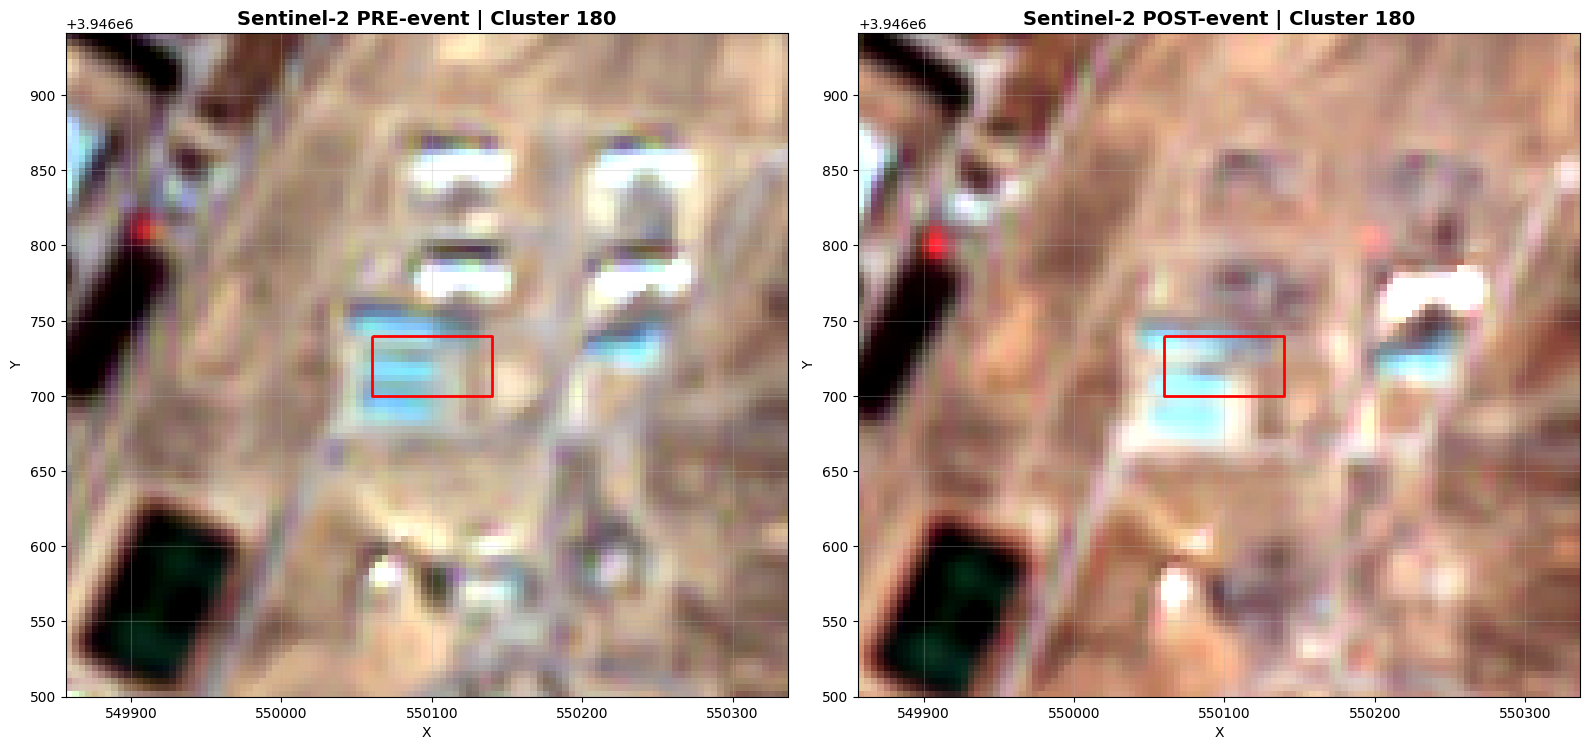

In [ ]:
row = selected_cluster.iloc[0]
cluster_label = row["cluster_id_seq"]

pre_extent = bounds_to_extent(pre_chip_bounds)
post_extent = bounds_to_extent(post_chip_bounds)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# PRE
axes[0].imshow(pre_rgb, extent=pre_extent, origin="upper")
plot_cluster_boundary(axes[0], selected_cluster, pre_crs, color="red", linewidth=2)
axes[0].set_title(f"Sentinel-2 PRE-event | Cluster {cluster_label}", fontsize=14, fontweight="bold")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")
axes[0].grid(True, alpha=0.3)

# POST
axes[1].imshow(post_rgb, extent=post_extent, origin="upper")
plot_cluster_boundary(axes[1], selected_cluster, post_crs, color="red", linewidth=2)
axes[1].set_title(f"Sentinel-2 POST-event | Cluster {cluster_label}", fontsize=14, fontweight="bold")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Y")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
from datetime import datetime

print("\n🖊️ Manual review input")
print("Allowed review_status values: yes / no / uncertain / skip")
print("Examples for review_type: destruction / construction / urban_change / false_positive / unclear")

row = selected_cluster.iloc[0]
cluster_id = row["cluster_id_seq"]

current_status = row.get("review_status", None)
current_type = row.get("review_type", None)
current_comment = row.get("review_comment", None)

print(f"\nCluster {cluster_id}")
print(f"Current review_status: {current_status}")
print(f"Current review_type: {current_type}")
print(f"Current review_comment: {current_comment}")

new_status = input("Enter review_status (yes/no/uncertain/skip) or press Enter to keep current: ").strip()
new_type = input("Enter review_type or press Enter to keep current: ").strip()
new_comment = input("Enter short comment or press Enter to keep current: ").strip()

# Keep old values if user presses Enter
if new_status == "":
    new_status = current_status
if new_type == "":
    new_type = current_type
if new_comment == "":
    new_comment = current_comment

# Update only selected cluster
mask = review_gdf["cluster_id_seq"] == cluster_id
review_gdf.loc[mask, "review_status"] = new_status
review_gdf.loc[mask, "review_type"] = new_type
review_gdf.loc[mask, "review_comment"] = new_comment
review_gdf.loc[mask, "review_date"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# Save immediately
save_review_table(review_gdf, review_geojson_path, review_csv_path)

print("\n✅ Review saved")
print(f"   cluster_id_seq: {cluster_id}")
print(f"   review_status: {new_status}")
print(f"   review_type: {new_type}")
print(f"   review_comment: {new_comment}")
print(f"   review_date: {review_gdf.loc[mask, 'review_date'].iloc[0]}")


🖊️ Manual review input
Allowed review_status values: yes / no / uncertain / skip
Examples for review_type: destruction / construction / urban_change / false_positive / unclear

Cluster 180
Current review_status: None
Current review_type: None
Current review_comment: None

✅ Review saved
   cluster_id_seq: 180
   review_status: yes
   review_type: None
   review_comment: None
   review_date: 2026-04-08 15:20:50


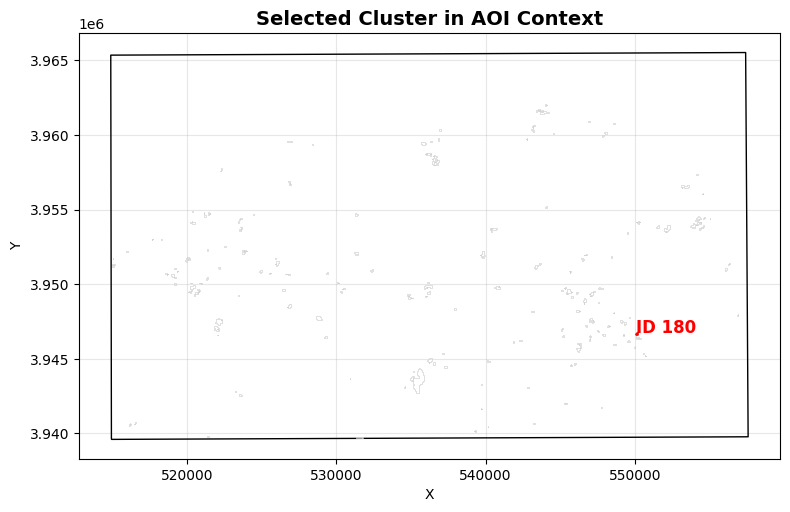

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))

aoi_gdf.boundary.plot(ax=ax, color="black", linewidth=1)
clusters_gdf.boundary.plot(ax=ax, color="lightgray", linewidth=0.5)
selected_cluster.boundary.plot(ax=ax, color="red", linewidth=2)

row = selected_cluster.iloc[0]
label_x, label_y = selected_geom.centroid.x, selected_geom.centroid.y
ax.text(label_x, label_y, f"ID {row['cluster_id_seq']}", color="red", fontsize=12, fontweight="bold")

ax.set_title("Selected Cluster in AOI Context", fontsize=14, fontweight="bold")
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()